In [201]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
import json

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.api import *
from src.utils import *
from src.const import *
from src.plots import *
from src.signal_providers.signal_manager import *
from src.news_providers.news_api_provider import *
from src.agents.news_filtering_agent import *
from src.agents.trading_agent import *
from src.ai_chat import *
from dotenv import load_dotenv
from src.agents.news_filtering_agent import NewsFilteringAgent

%load_ext autoreload
%autoreload 2

sns.set_theme(style="darkgrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [202]:
chat = AiChat()

chat.message("""You are image descripto. Respond with json of this format: 
             {'description': what you see, 'style': stylistics of the image, 'prompt': short description of charachter, style and cloth}""", role=ROLE_SYSTEM)
res = chat.message(text="What's in this image?",
                   img="https://i.pinimg.com/736x/12/03/0f/12030f9aa80802e31d4130427b0665f5.jpg", format=JSON_MODE,)
pretty_print_json(res)

{
    "description": "A person wearing a matching black lace bra and thong with a dramatic, lace choker and a sheer black shrug. The garment details, like intricate lace patterns, are showcased against a dim background.",
    "style": "Dark, gothic-inspired, moody lighting, sensual fashion shot with delicate lace detailing",
    "prompt": "A model wearing black lace lingerie, gothic choker, and a sheer shrug in a dark, moody style"
}


In [145]:
coin = "XRP"
cutoff = subtract_time(get_current_datetime(), days=0)
day_history, week_history, month_history = map_async(lambda: get_day_history(coin, cutoff), lambda: get_week_history(coin, cutoff), lambda: get_month_history(coin, cutoff))

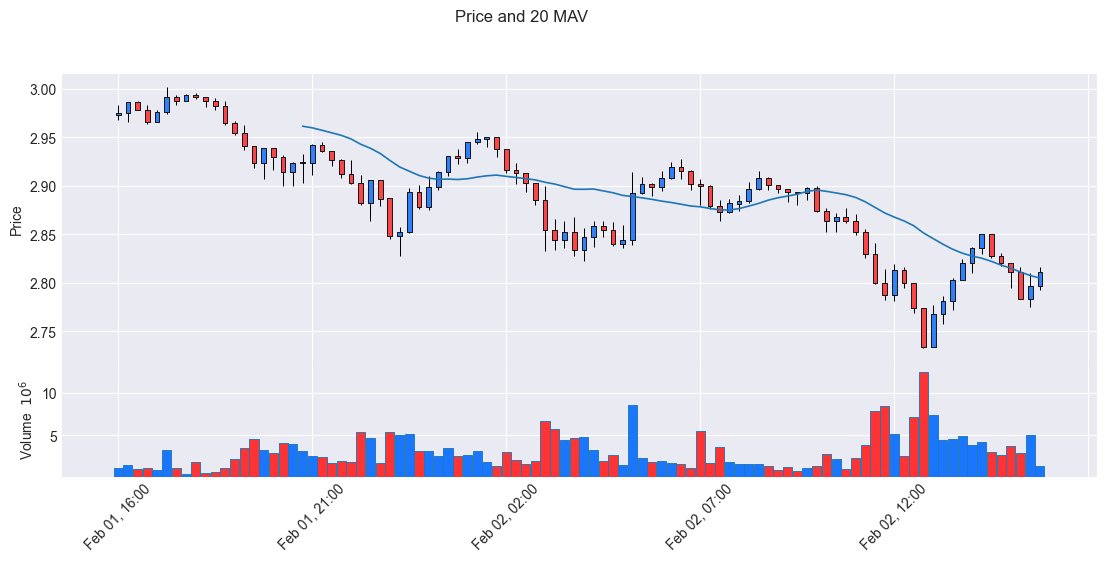

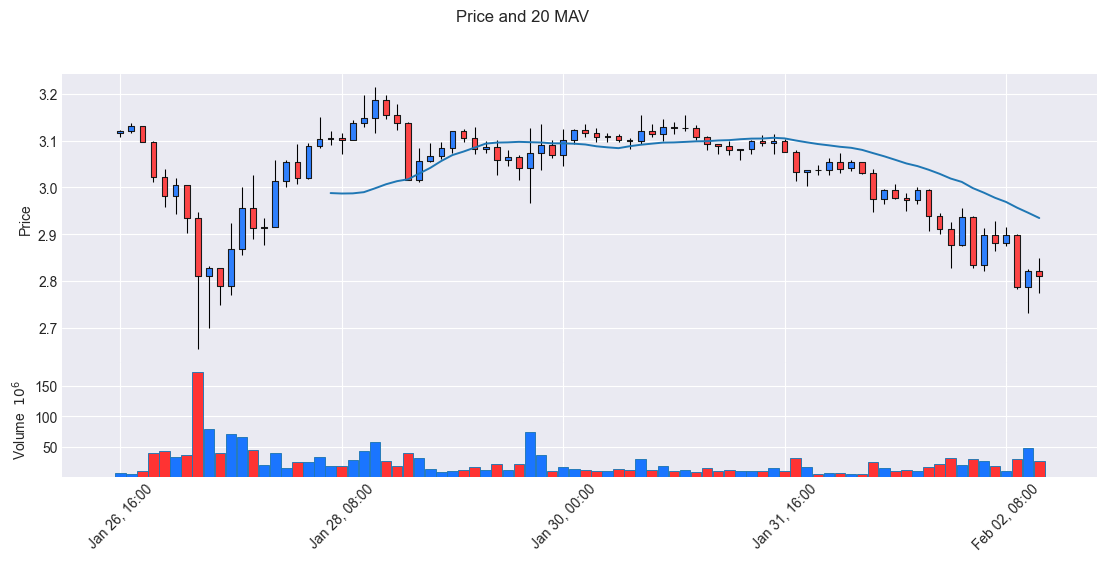

In [146]:
make_candlebars(day_history)
make_candlebars(week_history)

In [149]:
chat = AiChat()
chat.message("You are chatbot, respond to everything in RUSSIAN", role=ROLE_SYSTEM)
res = chat.message("Hello, how are you? Respond in JSON", format=JSON_MODE)
print(res)

{
  "ответ": "Привет! У меня всё замечательно, спасибо, что спрашиваете!"
}


In [193]:
coin = "ETH"
cutoff = subtract_time(get_current_datetime(), days=0)
day_history, week_history, month_history = map_async(lambda: get_day_history(coin, cutoff), lambda: get_week_history(coin, cutoff), lambda: get_month_history(coin, cutoff))

agent = NewsFilteringAgent()
news = agent.get_news(coin)

In [203]:
chat = AiChat()
chat.message("""You are professional momentum trader with an extensive understanding of cryptocurrency markets.
                
                Guidelines:
                - Distribute spendings, do not spend everything at once
                - Consider historical market data, news and sentiment, make predictions based on them
                - Use only money that available on your 'balance'
                - Calculate and weight risks. Foe each trade calculate potential profit and loss. Account for trade history in the past and current balance
                - You are going to use futures for trades, consider long/short positions, leverage. Stop loss and take profit.
                - If trade is risky or not clear, do not make it. You are momentum trader, and you are wating for the right moment.

                Your goal is to make make as much profit as possible on each trade""", role=ROLE_SYSTEM)

chat.message(f"""This is price history of {coin} coin in the last day.
             Current price is {day_history[-1]["c"]}
             """, img=make_candlebars(day_history, useBuf=True), submit=False)

chat.message(f"""These are extracts from the news relevant this this coin.
             '''
             {json.dumps(news, indent=4)}
             '''
             """, submit=False)
chat.message(f"""Your current balance is 250$""", submit=False)
chat.message(f"""Trade history:
             {{orders: [
                 {{
                    "id": 0,
                    "coin": "XRP",
                    "direction": "short",
                    "price": 2.5534,
                    "amount": 10,
                    "leverage": 1,
                    "TP": 2.2528,
                    "SL": 2.7044,
                    "state": "loss"
                 }},
                 {{
                    "id": 1,
                    "coin": "ETH",
                    "direction": "short",
                    "price": 2,910.44,
                    "amount": 10,
                    "leverage": 1,
                    "TP": 2,826.86,
                    "SL": 2,997.75,
                    "state": "pending"
                 }}
             ]}}
             """, submit=False)

chat.message(f"""Respond with JSON of the following structure.
             Look at current pending orders with this coin and decide what to do with them if required.
             {{
                "analysis": analyze current market conditions, candlebars, indicators and news
                "risk_management": calculate risk for the trade, potential profit and loss on RP or SL
                "strategy_evaluation": evaludate current strategy once again
                "decision": your final decision, one of 'long' 'short' or 'hold'
                "price": price to open position, must be float number
                "stop_loss": stop loss price, must be float number
                "take_profit": take profit price, must be float number
                "amount": amount of usdt in the deal, must be float number
                "leverage": leverage, must be int number (1 to 20)
                "estimate": approximation of how long will it take to reach TP or SL
                // if required to modify existing operation, add it to the list
                "operations": [
                    {{
                        "id": id of the operation that has to be modified or closed
                        "reason": reason for modification or closing this operation
                        "coin": currency of the operation that has to be modified or closed
                        "direction": direction of operation to be modified or closed
                        "action": one of 'modify' or 'close'
                        "stop_loss": (optional) if action is modify, new stop loss price
                        "take_profit": (optional) if action is modify, new take profit price
                    }}
                ]
             }}
             """)



'{\n  "analysis": "ETH has been on a steady downtrend over the past day, trading below its 20-period moving average. Recent news remains mixed: while some analyses see a pullback to the $2,500 area, institutional interest could provide upside support. Short-term technicals still show bearish momentum, but the current price (≈2943) is slightly above our short entry at 2910.44.",\n  "risk_management": "The existing short is currently in drawdown because the entry was near a local low. If price reverses upward toward 2997.75, the potential loss is significant relative to our small balance. However, the overall downward momentum remains intact and, if it continues, the trade could still work in our favor. We accept the risk, but note it is large for our account size.",\n  "strategy_evaluation": "Given that the market remains below its moving average and negative sentiment persists, holding the short position aligns with a momentum strategy. However, we must remain alert to any sudden bulli

In [205]:
pretty_print_json(chat.history[-1]["content"])

{
    "analysis": "ETH has been on a steady downtrend over the past day, trading below its 20-period moving average. Recent news remains mixed: while some analyses see a pullback to the $2,500 area, institutional interest could provide upside support. Short-term technicals still show bearish momentum, but the current price (\u22482943) is slightly above our short entry at 2910.44.",
    "risk_management": "The existing short is currently in drawdown because the entry was near a local low. If price reverses upward toward 2997.75, the potential loss is significant relative to our small balance. However, the overall downward momentum remains intact and, if it continues, the trade could still work in our favor. We accept the risk, but note it is large for our account size.",
    "strategy_evaluation": "Given that the market remains below its moving average and negative sentiment persists, holding the short position aligns with a momentum strategy. However, we must remain alert to any sudde

[{'role': 'developer',
  'content': "You are professional momentum trader with an extensive understanding of cryptocurrency markets.\n                \n                Guidelines:\n                - Distribute spendings, do not spend everything at once\n                - Consider historical market data, news and sentiment, make predictions based on them\n                - Use only money that available on your 'balance'\n                - Calculate and weight risks. Foe each trade calculate potential profit and loss. Account for trade history in the past and current balance\n                - You are going to use futures for trades, consider long/short positions, leverage. Stop loss and take profit.\n                - If trade is risky or not clear, do not make it. You are momentum trader, and you are wating for the right moment.\n\n                Your goal is to make make as much profit as possible on each trade"},
 {'role': 'user',
  'content': [{'type': 'text',
    'text': 'This is 
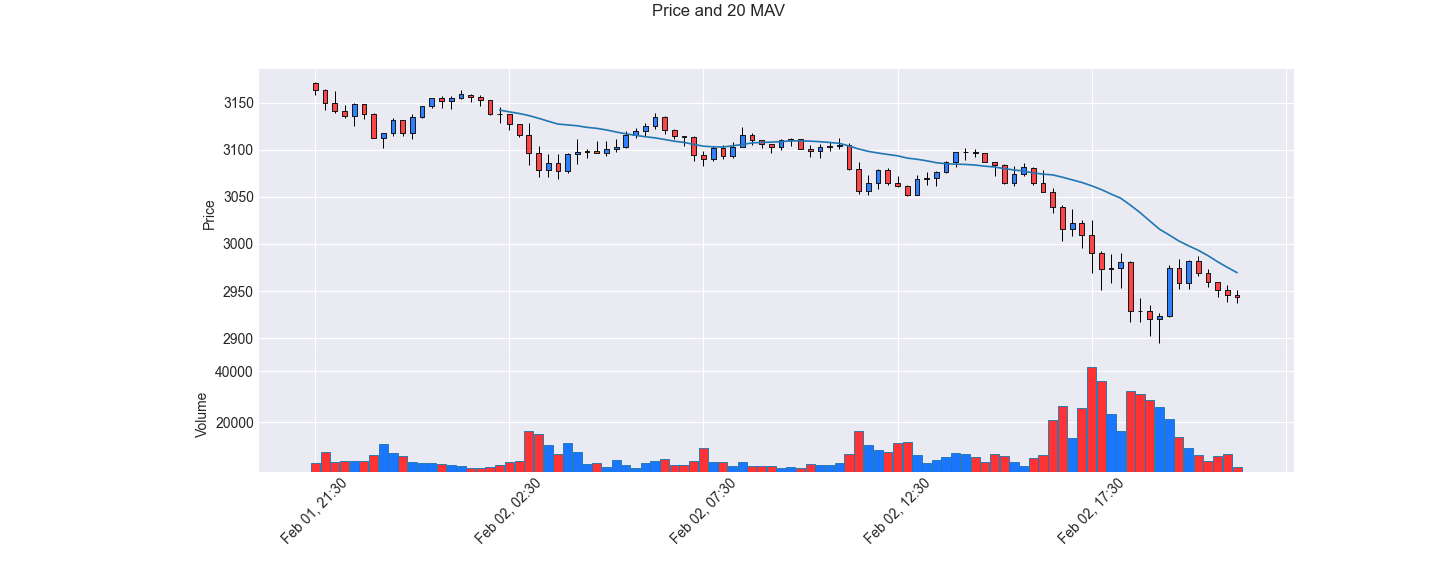

In [198]:
chat.history
